# install

In [ ]:
# !pip install langchain-google-genai langgraph
# !pip install llama_parse llama-index-core llama-index-readers-file python-dotenv
!pip install Levenshtein
# !pip install langchain_community
# !pip install langchain_openai langchain_google_genai langchain langchain_community langchain_core langgraph
# !pip install lancedb
# !pip install Literal

# import

In [17]:
from langchain_core.messages import HumanMessage, SystemMessage

from typing import TypedDict, Optional
from pydantic import BaseModel, Field

from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

from langchain_community.tools.tavily_search import TavilySearchResults

from typing import TypedDict, List, Dict, Any, Annotated

# api keys

In [2]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env('GOOGLE_API_KEY')
_set_env('LLAMA_API_KEY')
_set_env('TAVILY_API_KEY')

GOOGLE_API_KEY: ··········
LLAMA_API_KEY: ··········
TAVILY_API_KEY: ··········


# llama parser

In [3]:
import nest_asyncio
nest_asyncio.apply()

from llama_parse import LlamaParse

parser = LlamaParse(result_type='text', api_key=os.environ['LLAMA_API_KEY'])

# parse the book

In [4]:
from llama_index.core import SimpleDirectoryReader

pdf_file = '/content/drive/MyDrive/nlp/The New Complete Book of Foos.pdf'
data_for_parse = SimpleDirectoryReader(input_files=[pdf_file], file_extractor={'.pdf': parser})
documents = data_for_parse.load_data()
len(documents)

Started parsing the file under job_id 163a344e-1558-48e6-9ef2-54fde4f30816


497

# chunking

In [5]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1024,
    chunk_overlap=64,
    length_function=len,
    is_separator_regex=False,
)


documents_list = []
page_number = 0
last_doc = None
for doc in documents:
    if last_doc is None or last_doc != doc.metadata["file_name"]:
        page_number = 1
        last_doc = doc.metadata["file_name"]
    else:
        page_number += 1

    texts = text_splitter.split_text(doc.text)
    for text in texts:
        item = {}
        item["id_"] = doc.id_
        item["text"] = text
        item["metadata_file_name"] = doc.metadata["file_name"]
        item["metadata_creation_date"] = doc.metadata["creation_date"]
        item["metadata_pagenumber"] = page_number
        documents_list.append(item)
len(documents_list)

1737

# dataframe

In [6]:
import pandas as pd

df = pd.DataFrame(documents_list)
df.head()

,id_,text,metadata_file_name,metadata_creation_date,metadata_pagenumber
0,e0629277-7efe-460c-ae8d-9b6921ce960d,The New\nComplete Book of\nFOOD\n 5 eE0 n d ...,The New Complete Book of Foos.pdf,2025-01-29,1
1,b535b7b2-6ad9-4a02-a858-59fc4bd2d00c,The New\nFood\n Complete Book of\n S e c ...,The New Complete Book of Foos.pdf,2025-01-29,2
2,ceb42345-f99b-479b-b14d-7225a3cc5704,NO_CONTENT_HERE,The New Complete Book of Foos.pdf,2025-01-29,3
3,b12e4e4b-df3e-45e2-b15b-960008b48b58,The New\nFood\n Complete Book of\n S e c...,The New Complete Book of Foos.pdf,2025-01-29,4
4,118a615d-0c9d-40fb-b2a4-f2a43f6d0fa1,"The New Complete Book of Food, Second Edition\...",The New Complete Book of Foos.pdf,2025-01-29,5


# to db

In [ ]:
import lancedb
from lancedb.embeddings import get_registry
from lancedb.pydantic import LanceModel, Vector

db = lancedb.connect(".lancedb")
embedding_model = get_registry().get("sentence-transformers").create(name="BAAI/bge-small-en-v1.5")


class ChunksOfData(LanceModel):
    id_: str
    text: str = embedding_model.SourceField()
    metadata_file_name: str
    metadata_creation_date: str
    metadata_pagenumber: int
    vector: Vector(embedding_model.ndims()) = embedding_model.VectorField()

def df_to_dict_batches(df: pd.DataFrame, batch_size: int = 128):
    for start_idx in range(0, len(df), batch_size):
        end_idx = start_idx + batch_size
        batch_dicts = df.iloc[start_idx:end_idx].to_dict(orient="records")
        yield batch_dicts

# table

In [10]:
tbl = db.create_table(
    "embedded_chunks",
    data=df_to_dict_batches(df, batch_size=10),
    schema=ChunksOfData,
    mode="overwrite"
)

# a query to db

In [11]:
query = "What is pizza?"
tbl.create_fts_index('text', use_tantivy=False)

tbl.search(query, query_type="hybrid").limit(5).to_pandas()

,id_,text,metadata_file_name,metadata_creation_date,metadata_pagenumber,vector,_relevance_score
0,5ad8164b-9612-4015-94a1-198cc0480b13,What You Will Find in This Book\n The infor...,The New Complete Book of Foos.pdf,2025-01-29,15,"[-0.0029358503, -0.052339554, 0.0015591768, -0...",0.032002
1,74af893e-69a4-44e2-bd68-cdc4494435cf,What Happens When You Cook This Food\nToasting...,The New Complete Book of Foos.pdf,2025-01-29,81,"[-0.049284402, 0.029307479, -0.012760689, -0.0...",0.016393
2,5ad8164b-9612-4015-94a1-198cc0480b13,What is new is that today we understand the sc...,The New Complete Book of Foos.pdf,2025-01-29,15,"[-0.00039118016, -0.0038443254, 0.069003835, 0...",0.016393
3,bf96d4db-47f8-4b12-abbc-e844b53db3de,Pork,The New Complete Book of Foos.pdf,2025-01-29,336,"[-0.0038336962, 0.07073762, -0.022021113, -0.0...",0.016129
4,5baaa62a-0172-486a-b837-3f3ad352975d,What Happens When You Cook This Food\n Heat ...,The New Complete Book of Foos.pdf,2025-01-29,283,"[-0.04036668, 0.008415325, -0.006424615, 0.002...",0.015873


# sub-graph of taks-1 (informative bot)

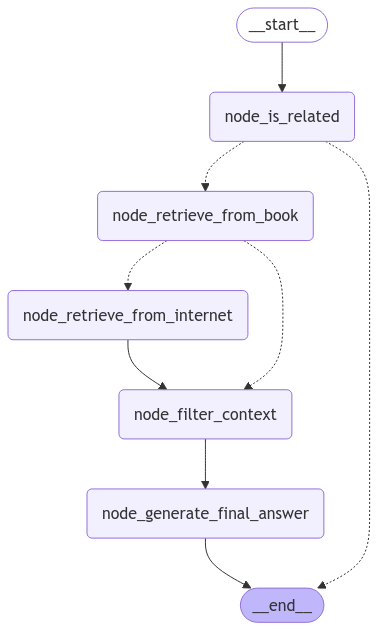

In [268]:
class Task1State(TypedDict):
    user_prompt: str
    is_related: bool
    raw_context: List[str] # either retrieved_from_book or retrieved_from_internet
    filtered_context: str
    final_answer: str

class RealatednessStructure(BaseModel):
    is_related: bool = Field(description="True if the user's prompt is related to food matters, otherwise False.")

def node_is_related(state: Task1State) -> Task1State:
    print('\n----------- node_is_related ----------')
    user_prompt = state['user_prompt']
    print(f'user_prompt: {user_prompt}')
    is_related = model.with_structured_output(RealatednessStructure).invoke(user_prompt).is_related
    print('bura')
    if not is_related: state['final_answer'] = 'apologies, but this prompt is unrelated to food matters'
    state['is_related'] = is_related
    return state


class BookUsefulnessStructure(BaseModel):
    is_useful: bool = Field(description="True if the provided information is sufficient to answer the user's prompt, otherwise False.")

def node_retrieve_from_book(state: Task1State) -> Task1State:
    print('\n----------- node_retrieve_from_book ----------')
    user_prompt = state['user_prompt'].lower()
    results = tbl.search(state['user_prompt'], query_type='hybrid').limit(3).to_list()
    book_context_list = [result['text'] for result in results]
    print(f'book_context_list: {book_context_list}')
    information_retrieved_from_book = ' '.join(book_context_list).lower()

    llm_prompt = [
        SystemMessage(f"Given the following information: {information_retrieved_from_book}, determine whether it is sufficient to answer the user's prompt."),
        HumanMessage(user_prompt),
    ]
    is_useful = model.with_structured_output(BookUsefulnessStructure).invoke(llm_prompt).is_useful
    print(f'is_useful: {is_useful}')
    state['raw_context'] = information_retrieved_from_book if is_useful else []
    return state


def node_retrieve_from_internet(state: Task1State) -> Task1State:
    print("\nEntering node_retrieve_from_internet")
    results = TavilySearchResults(max_results=3).invoke(state["user_prompt"])
    state["retrieved_from_internet"] = [r["content"] for r in results]
    state['raw_context'] = state["retrieved_from_internet"]
    print("Exiting node: search_internet\n")
    return state

def node_filter_context(state: Task1State) -> Task1State:
    print("\nnode_filter_context")
    raw_context = state['raw_context']
    prompt = ( f"User Query: {state['user_prompt']}\n\n"
        f"Context:\n{raw_context}\n\n remove any irrelevant information and keep only the context relevant to answering the query." )

    filtered = model.invoke(prompt).content
    state["filtered_context"] = filtered
    print("\n-----Filtered Context-----")
    print(f'raw_context: {raw_context}')
    print(f'filtered: {filtered}')
    print("Exiting node: filter_context\n")
    return state

def node_generate_final_answer(state: Task1State) -> Task1State:
    print("\nEntering node_generate_final_answer")
    context = state.get("filtered_context", "")
    prompt = (
        f"User Query: {state['user_prompt']}\n\n"
        f"Relevant Context:\n{context}\n\n"
        "Based on the above, please generate a concise and accurate answer to the user's query."
    )
    answer = model.invoke(prompt).content
    state["final_answer"] = answer
    print("Exiting node_generate_final_answer\n")
    return state


from langgraph.graph import END
from typing import Literal

def related_condition(state: Task1State) -> Literal['node_retrieve_from_book', END]:
    """
    If the query is related (is_related==True), branch to retrieve book context.
    Otherwise, immediately end the graph (using END) so that the final answer set in is_related is returned.
    """
    print("\nEntering conditional for 'node_is_related'")
    if state.get("is_related"):
        print("Query is related to Chat Food. Branching to node_retrieve_from_book.")
        return "node_retrieve_from_book"
    else:
        print("Query is not related to Chat Food. Ending graph.")
        return END  # end the graph immediately

def need_internet_search(state: Task1State) -> Literal['node_retrieve_from_internet', 'node_filter_context']:
    raw_context = state.get("raw_context", [])
    if raw_context == []:
        return "node_retrieve_from_internet"
    else:
        return "node_filter_context"



builder = StateGraph(Task1State)

builder.add_node("node_is_related", node_is_related)
builder.add_node("node_retrieve_from_book", node_retrieve_from_book)
builder.add_node("node_retrieve_from_internet", node_retrieve_from_internet)
builder.add_node("node_filter_context", node_filter_context)
builder.add_node("node_generate_final_answer", node_generate_final_answer)

builder.add_edge(START, "node_is_related")

builder.add_conditional_edges("node_is_related", related_condition)
builder.add_conditional_edges("node_retrieve_from_book", need_internet_search)

builder.add_edge("node_retrieve_from_internet", "node_filter_context")
builder.add_edge("node_filter_context", "node_generate_final_answer")
builder.add_edge("node_generate_final_answer", END)

informative_graph = builder.compile()

from IPython.display import Image, display
display(Image(informative_graph.get_graph().draw_mermaid_png()))

# taks-1 (informative) to tools for the main chatbot


In [301]:
def tool_process_user_queries_and_decide(prompt: str) -> str:
    """
    Processes user queries and decide whether they are related to food matters or ouside the scope and no need to answer them.
    The flow follows a decision-making structure, ensuring that the most relevant and accurate food-related information is retrieved, filtered, and presented as a final answer.

    Flow Overview
    Check if the Query is Food-Related → (is_related)
    Retrieve Food Information from a Book Database → (retrieve_from_book)
    If the Book Lacks Relevant Information, Search the Internet → (search_internet)
    Filter the Retrieved Information to Keep Only Relevant Context → (filter_context)
    Generate a Final Answer Based on the Processed Context → (generate_final_answer)

    If food-related: Well-structured, concise answer based on verified sources.
    If not food-related: Immediate rejection response.

    The system ensures that only high-quality, relevant food-related information is returned!

    Args:
        query (str): The user's query related to food and restaurants or not.

    """
    # Initialize the state.
    state: Task1State = {
        "user_prompt": prompt,
        "is_related": False,
        "raw_context": [],
        "internet_context": [],
        "filtered_context": "",
        "final_answer": ""
    }

    final_state = chat_food_info_graph.invoke(state)
    final_answer = final_state.get("final_answer", "No answer produced.")
    print("Final Answer:")
    print(final_answer)
    return final_state

# tools for taks-2 (order-related)

In [257]:
class ActionEctractionStructure(BaseModel):
    action: List[str] = Field(description='cancel/status/comment/unkknow')

def tool_extract_action_type_from_query(query: str) -> str:
    """
    Extracts the order-relating action type from the user's query.

    The function examines the query and returns one of the following actions:
      - "cancel"  : if the query indicates a desire to cancel an order.
      - "status"  : if the query is about checking the order status.
      - "comment" : if the query mentions commenting or providing feedback on an order.
      - 'unknown' : if no recognized order-related action is found.


    Args:
        query: The user's query as a string.

    Returns:
        A string indicating the action type. If no related action to order is found, returns "unknown".
    """
    llm_prompt = [
        SystemMessage(f"""
        Your task is to extract the action type from the user's query.
        Examine the query and return one of the following actions:
        - 'cancel'  : if the query indicates a desire to cancel an order.
        - 'status'  : if the query is about checking the order status.
        - 'comment' : if the query mentions commenting or providing feedback on an order.
        - 'unknown' : if no recognized order-related action is found.
        """),
        HumanMessage(query),
    ]
    llm_response = model.with_structured_output(ActionEctractionStructure).invoke(llm_prompt)
    action = llm_response.action
    print(f'action: {action}')
    return action


def tool_manage_order(action: str, order_id: int, phone_number: str = None, person_name: str = None, comment: str = None) -> str:
    """
    Manages order-related operations such as canceling an order, checking order status, and adding or updating a comment.

    Depending on the specified action, this function performs one of the following operations:

    1. Cancel an order:
       - Action: 'cancel'
       - Required Args: order_id, phone_number
       - Returns:
         - If the order does not exist:
           - "Order ID {order_id} from {phone_number} does not exist."
         - If the order was successfully canceled:
           - "Order ID {order_id} from {phone_number} has been successfully canceled."
         - If the order cannot be canceled due to its current status:
           - "Order ID {order_id} from {phone_number} cannot be canceled as it is in '{current_status}' status."

    2. Check order status:
       - Action: 'status'
       - Required Args: order_id
       - Returns:
         - If the order does not exist:
           - "Order ID {order_id} does not exist."
         - If the order exists:
           - "Order ID {order_id} is currently in '{status}' status."

    3. Add or update a comment for an order:
       - Action: 'comment'
       - Required Args: order_id, person_name, comment
       - Returns:
         - If the order does not exist:
           - "Order ID {order_id} does not exist."
         - If the comment was successfully updated:
           - "Comment for Order ID {order_id} from {person_name} has been updated."

    Args:
        action: The action to perform ('cancel', 'status', or 'comment').
        order_id: The unique identifier of the order.
        phone_number: The phone number associated with the order (required for 'cancel' action).
        person_name: The name of the person leaving the comment (required for 'comment' action).
        comment: The text of the comment to be added or updated (required for 'comment' action).

    Returns:
        A string message describing the result of the specified action.
    """
    if action == 'cancel':
        if phone_number is None:
            return "Phone number is required for canceling an order."
        return cancel_order(order_id, phone_number)

    elif action == 'status':
        return check_order_status(order_id)

    elif action == 'comment':
        if person_name is None or comment is None:
            return "Person name and comment are required for adding or updating a comment."
        print('\nwe are here\n')
        print(f'order_id: {order_id}, person_name: {person_name}, comment: {comment}')
        zz = comment_order(order_id, person_name, comment)
        print(f'zz: {zz}')
        return zz

    else:
        return "Invalid action specified. Please choose 'cancel', 'status', or 'comment'."

# tools for taks-3 (pricing information)

In [258]:
def tool_search_price_just_by_food_name(food_name: str) -> List[Dict]:
    """ searches for prices of a particular food across different restaurants.
    Args:
        food_name: food name to search for.
    """
    matching_foods = food_search(food_name=food_name)
    return matching_foods


def tool_search_price_just_by_restaurant_name(restaurant_name: str) -> List[Dict]:
    """ searches for prices of foods of a particular restaurant.
    Args:
        restaurant_name: Restaurant name to search for (optional)
    """
    matching_foods = food_search(restaurant_name=restaurant_name)
    return matching_foods


def tool_search_price_by_both_food_name_and_restaurant_name(food_name: str, restaurant_name: str) -> List[Dict]:
    """ searches for price of a particular food of a particular restaurant.
    Args:
        food_name: Food name to search for
        restaurant_name: Restaurant name to search for
    """
    matching_foods = food_search(food_name=food_name, restaurant_name=restaurant_name)
    return matching_foods

# tools for taks-4 (suggesting)


In [297]:
class SuggestionStructure(BaseModel):
    food_name_list: List[str] = Field(description="A list of suggested food names based on the user's preference.")

class FoodSuggestionEvaluation(BaseModel):
    additional_suggestions_required: bool = Field(description="True if none of the provided foods have price or restaurant details, otherwise False.")
    pricing_information: str = Field(description="pricing information of available foods")

class FoodSuggestionUpdate(BaseModel):
    new_food_suggestions: List[str] = Field(description="A list of newly suggested food names that match the given food category.")

def foods_search(food_name_list):
    matching_foods_list = []
    for food_name in food_name_list:
        matching_foods = food_search(food_name=food_name)
        for item in matching_foods: matching_foods_list.append(item)
    return matching_foods_list

def tool_suggest_foods_and_check_database(desired_food_attributes_for_suggestion: str) -> List[str]:
    """
    Suggests food items based on the provided food category.
    And then searches for the availability and prices of suggested suggested foods across different restaurants.

    This function checks if each food item in the provided list exists in the database and retrieves
    relevant pricing information from various restaurants.

    Args:
        desired_food_attributes_for_suggestion: Anything representing the user's desired food attributes and can suggest based on.
        This may include the type of dish, flavor profile, cuisine or nationality,
        dietary restrictions, or any other characteristic that helps define the user's food preference

    Returns:
        A list of dictionaries, where each dictionary contains details (such as food name, restaurant, and price)
        for the matching food items. If a food item is not found, it will not appear in the results
    """
    print('\nusing t_suggest_foods_and_then_check_database\n')


    llm_prompt = [
        SystemMessage("The user wants food suggestions based on their preferred category. Suggest 3-5 relevant foods."),
        HumanMessage(desired_food_attributes_for_suggestion),
    ]
    # print('vvvvvvv')

    llm_response = model.with_structured_output(SuggestionStructure).invoke(llm_prompt)
    food_name_list = llm_response.food_name_list
    print(f'first food_name_list: {food_name_list}')

    matching_foods_list = foods_search(food_name_list)
    print(matching_foods_list, '\n')

    llm_prompt = [
        SystemMessage(f"""Your task is to evaluate the food names provided by the user against the database results: {matching_foods_list}.
                    Determine whether price and restaurant information is available for at least one of them.
                    - If none of the foods have price or restaurant data, set `additional_suggestions_required` to **True**.
                    - If at least one food has pricing and restaurant details,
                        set `additional_suggestions_required` to **False**, and give those food names and their pricing information in the `food_name_list` field.
        """),
        HumanMessage(f"Here are the suggested foods: {food_name_list}")
    ]
    llm_response = model.with_structured_output(FoodSuggestionEvaluation).invoke(llm_prompt)
    # print(f'xxx: {llm_response}')
    additional_suggestions_required = llm_response.additional_suggestions_required
    print(f'additional_suggestions_required: {additional_suggestions_required}')
    pricing_information = llm_response.pricing_information
    print(f'pricing_information: {pricing_information}')

    if not additional_suggestions_required: return pricing_information

    llm_prompt = [
        SystemMessage(content=f"""
            You are a food suggestion evaluator.
            Your task is to review the suggested foods for the category "{desired_food_attributes_for_suggestion}" and generate completely new food suggestions that fit this category.
        """),
        HumanMessage(f"Here are the previously suggested foods: {food_name_list}")
    ]

    llm_response = model.with_structured_output(FoodSuggestionUpdate).invoke(llm_prompt)
    new_food_suggestions = llm_response.new_food_suggestions
    print(f'new_food_suggestions: {new_food_suggestions}')

    matching_foods_list = foods_search(new_food_suggestions)
    print(f'here: {matching_foods_list}')
    return matching_foods_list

In [306]:
cnx = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM food_orders", cnx)
df

,id,person_name,person_phone_number,status,order_description,comment
0,1,Alice,123-456-7890,canceled,Kebab and Chicken Kebab,The food was great.
1,2,Bob,987-654-3210,delivery,Pizza and Fried Chicken,The food was great.
2,3,Charlie,555-666-7777,canceled,Sushi platter,Payment issue
3,4,Diana,444-333-2222,delivered,Burger and Ice Cream,Delicious meal!
4,5,Eve,222-333-4444,preparation,Steak,
...,...,...,...,...,...,...
67,68,Julian,098-321-7656,delivered,Chicken Curry and Naan,Spicy and delicious
68,69,Scarlett,109-432-8767,preparation,Chicken Parmesan and Pasta,Extra cheese was needed
69,70,Levi,210-543-9878,delivery,Chicken Alfredo and Garlic Bread,Extra sauce
70,71,Layla,321-654-0980,canceled,Chicken Tacos and Guacamole,Spicy and delicious


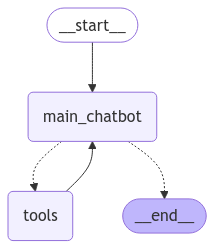

In [302]:
tools = [
            tool_process_user_queries_and_decide,
            tool_extract_action_type_from_query,
            tool_manage_order,
            tool_search_price_just_by_food_name,
            tool_search_price_just_by_restaurant_name,
            tool_search_price_by_both_food_name_and_restaurant_name,
            tool_suggest_foods_and_check_database,
        ]
llm_with_tools = model.bind_tools(tools)


sys_msg = SystemMessage(
    content="""
        You are a smart chatbot designed to assist users with food-related queries.
        Whenever possible, prioritize using the available tools instead of relying solely on your own knowledge.
    """
)

def main_chatbot(state: MessagesState):
    print("-------------Reasoner----------------")
    messages = [sys_msg] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


builder = StateGraph(MessagesState)

builder.add_node("main_chatbot", main_chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "main_chatbot")
builder.add_conditional_edges("main_chatbot", tools_condition)
builder.add_edge("tools", "main_chatbot")

memory = MemorySaver()
app = builder.compile(checkpointer=memory)
config = {"configurable": {"thread_id": "1457"}}

from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [312]:
last_input_message = 'hi'

while last_input_message != 'exit':
    output = app.invoke({"messages": [HumanMessage(last_input_message)]}, config)
    output["messages"][-1].pretty_print()
    last_input_message = input('\nenter your message: ')

-------------Reasoner----------------
================================== Ai Message ==================================

Hello! How can I help you?
-------------Reasoner----------------
================================== Ai Message ==================================

I'm sorry, I cannot answer questions that are outside the scope of food and restaurants.
-------------Reasoner----------------

----------- node_is_related ----------

Entering conditional for 'node_is_related'
Query is related to Chat Food. Branching to node_retrieve_from_book.

----------- node_retrieve_from_book ----------
book_context_list: ['r   Beer\n     (Ale)\no\n     Nutritional Profile\n  3                                                Energy value (calories per serving): Low\n     Protein: Moderate\n]\n     Fat: None\n     Saturated fat: None\n     Cholesterol: None\n     Carbohydrates: High\n1    Fiber: None\n     Sodium: Low\n     Major vitamin contribution: B vitamins\n     Major mineral contribution: Phospho